In [1]:
pip install pandas scikit-learn matplotlib

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 3.2 MB/s eta 0:00:03
   ------------------ --------------------- 3.9/8.3 MB 9.3 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 14.5 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 11.1 MB/s  0:00:00
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   - -------------------------------------- 1.8/37.4 MB 54.2 MB/s eta 0:00:01
   --- ------------------------------------ 3.1/37.4 MB 9.2 MB/s eta 0:00:04
   --------- ------------------------------ 8.9/37.4 MB 13.8 MB/s eta 0:00:03
   ------------------- -------------------- 18.6/37.4 MB 21.5 MB/s eta 0:00:01
   --------------------------- ------------ 25.7/37.4 MB 23.8 MB/s eta 0:00:01
   ---------------------------------- ----- 32.5/37.4 MB 25.2 MB/s eta 0:00:01
   ----------------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from pathlib import Path

script_dir = Path("scripts")

files = []
filenames = []

for file in script_dir.glob("*.txt"):
    with open(file, 'r', encoding='utf-8') as f:
        files.append(f.read())
        filenames.append(file.name)

print(filenames)

['script1.txt', 'script2.txt', 'script3.txt', 'script4.txt', 'script5.txt', 'script6.txt']


In [3]:
df = pd.DataFrame({'filename': filenames, 'content': files})
print(df)

      filename                                            content
0  script1.txt  The government has announced a new policy.\nTh...
1  script2.txt  Mum wants everyone home for dinner.\nDad is wo...
2  script3.txt  The detective examined the evidence.\nPolice a...
3  script4.txt  The prime minister addressed parliament.\nThe ...
4  script5.txt  My brother never listens to me.\nMum says we n...
5  script6.txt  The police discovered new evidence.\nThe detec...


In [4]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['content'])
print(vectorizer.get_feature_names_out())

['about' 'addressed' 'after' 'already' 'announced' 'another' 'argue'
 'arguing' 'arrested' 'as' 'at' 'attacked' 'begun' 'brother' 'campaign'
 'children' 'continued' 'criticised' 'dad' 'decide' 'decision' 'defended'
 'detective' 'dinner' 'discovered' 'economic' 'election' 'everyone'
 'evidence' 'examined' 'family' 'for' 'government' 'has' 'her' 'home'
 'house' 'identified' 'in' 'investigation' 'is' 'listens' 'me' 'minister'
 'missing' 'morning' 'moving' 'mps' 'mum' 'my' 'need' 'never' 'new'
 'night' 'opposition' 'parliament' 'police' 'policy' 'prime' 'promised'
 'questioned' 'reform' 'revealed' 'sarah' 'says' 'stop' 'suspect' 'talk'
 'the' 'they' 'this' 'throughout' 'to' 'upstairs' 'voters' 'wants' 'we'
 'weapon' 'went' 'will' 'witness' 'worried']


In [5]:
print(X.shape)

(6, 82)


In [6]:
tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=df["filename"]
)

print(tfidf_df.round(2))

             about  addressed  after  already  announced  another  argue  \
filename                                                                   
script1.txt   0.00       0.00    0.0      0.2        0.2     0.00   0.00   
script2.txt   0.42       0.00    0.0      0.0        0.0     0.00   0.21   
script3.txt   0.00       0.00    0.0      0.0        0.0     0.00   0.00   
script4.txt   0.00       0.22    0.0      0.0        0.0     0.00   0.00   
script5.txt   0.00       0.00    0.2      0.0        0.0     0.00   0.00   
script6.txt   0.00       0.00    0.0      0.0        0.0     0.22   0.00   

             arguing  arrested   as  ...    to  upstairs  voters  wants   we  \
filename                             ...                                       
script1.txt      0.0      0.00  0.0  ...  0.00       0.0    0.00   0.00  0.0   
script2.txt      0.0      0.00  0.0  ...  0.17       0.0    0.00   0.17  0.0   
script3.txt      0.0      0.23  0.0  ...  0.00       0.0    0.00   0.00

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)
df["cluster"] = kmeans.labels_
print(df[["filename", "cluster"]])

      filename  cluster
0  script1.txt        2
1  script2.txt        1
2  script3.txt        0
3  script4.txt        2
4  script5.txt        1
5  script6.txt        0


In [8]:
terms = vectorizer.get_feature_names_out()

for cluster_num, centre in enumerate(kmeans.cluster_centers_):
    top_indices = centre.argsort()[-10:][::-1]

    print(f"\nCluster {cluster_num}")

    for index in top_indices:
        print(terms[index], round(centre[index], 3))


Cluster 0
the 0.551
detective 0.28
suspect 0.276
witness 0.186
questioned 0.186
investigation 0.186
police 0.186
evidence 0.186
this 0.116
weapon 0.116

Cluster 1
to 0.333
about 0.212
says 0.169
family 0.169
dad 0.169
everyone 0.169
mum 0.169
listens 0.169
never 0.169
dinner 0.169

Cluster 2
the 0.466
minister 0.262
government 0.255
has 0.201
policy 0.172
opposition 0.172
parliament 0.172
election 0.172
voters 0.109
prime 0.109


In [9]:
pca = PCA(n_components=2)

X_2d = pca.fit_transform(X.toarray())

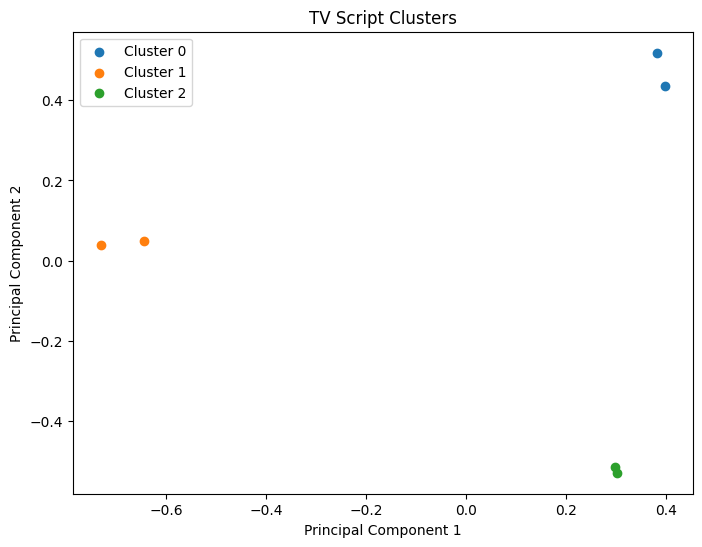

In [10]:
plt.figure(figsize=(8, 6))

for cluster in sorted(df["cluster"].unique()):
    points = X_2d[df["cluster"] == cluster]

    plt.scatter(
        points[:, 0],
        points[:, 1],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("TV Script Clusters")
plt.legend()

plt.show()

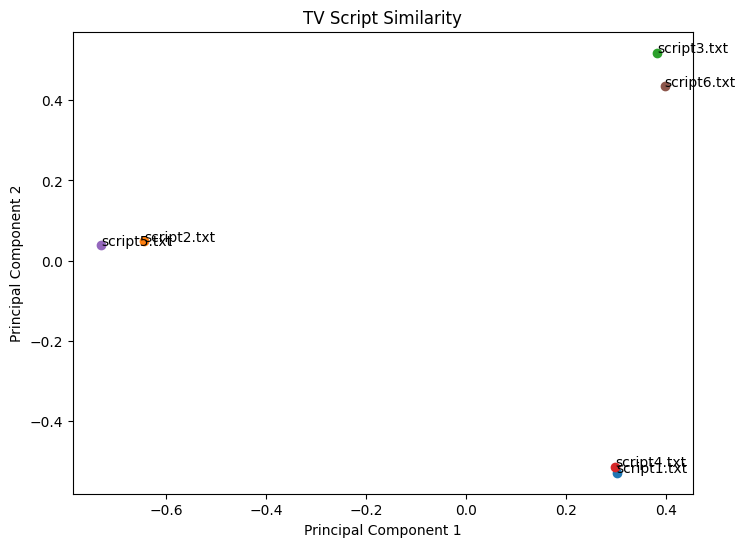

In [11]:
plt.figure(figsize=(8, 6))

for i, row in df.iterrows():
    plt.scatter(X_2d[i, 0], X_2d[i, 1])
    plt.annotate(
        row["filename"],
        (X_2d[i, 0], X_2d[i, 1])
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("TV Script Similarity")

plt.show()